# 제주 특산물 가격 예측 - 달력 피처 + 시즌 Hold-Out v5.0.0

| 항목 | 내용 |
|------|------|
| **버전** | v5.0.0 |
| **날짜** | 2026-03-16 |
| **모델** | CatBoost + LightGBM (VotingRegressor 방식) |
| **검증** | **시즌 기반 Hold-Out** — 2022년 3월 (테스트와 동일 조건) |
| **전처리** | 1등 코드 기반 + 명절 접근 거리 피처 |
| **출력** | results/submission_v5.0.0.csv |

## v5.0.0 변경 내용

| 항목 | v4.2.0 | v5.0.0 | 근거 |
|------|--------|--------|------|
| 피처 | 기본 7개 + one-hot | 기본 7개 + **명절 거리 2개** + one-hot | 가격은 설날·추석 접근 시 급등 |
| 검증 | 없음 (전체 학습) | **2022-03 Hold-Out** → 전체 재학습 | 제출 전 신뢰 가능한 MAE 확보 |
| 달력 피처 | — | dist_seollal, dist_chuseok | 날짜 기반 계산 → 테스트 freeze 없음 |

## 왜 달력(회귀) 접근인가

- v1.0.1(Public 658.6)이 **달력 7개 피처만으로** 최고 점수를 냈음
- 지배적인 신호 = **계절성(seasonality)** — 가격이 매년 비슷한 패턴 반복
- 시계열 모델(LSTM)이나 래그 피처(EMA)는 오히려 과적합 또는 테스트 freeze로 손해
- **회귀 모델 + 달력 피처 = 가장 단순하고 강건한 baseline**

## 왜 시즌 기반 Hold-Out인가

- 테스트 = 2023년 3월 → 검증도 같은 조건: **2022년 3월**
- 랜덤 K-Fold는 미래 데이터를 학습에 포함시켜 MAE를 낙관적으로 만듦
- 검증 MAE와 Public Score 배율(×1.26 이하)을 유지하는 것이 목표

---
## 버전 히스토리

| 버전 | 모델 | 핵심 변경 | Public | Private |
|------|------|----------|---------|----------|
| v1.0.1 | DNN | DACON 1위 전처리 | **658.6** ✅ | 825.0 |
| v4.0.0 | LGB+CB | 트리 앙상블 전환 | 672.5 | 854.7 |
| v4.1.0 | LGB+CB | EMA 피처 추가 | 1170.5 ❌ | 1241.9 |
| v4.2.0 | LGB+CB | 1등 기반 재설계 | — | — |
| **v5.0.0** | **LGB+CB** | **달력 피처 + Hold-Out 검증** | — | — |

---
## 1. 라이브러리 로드

In [1]:
# lightgbm이 없는 환경을 위해 자동 설치
# CatBoost, holidays는 기본 환경에 있다고 가정
try:
    import lightgbm as lgb
except ImportError:
    import subprocess; subprocess.run(['pip', 'install', 'lightgbm'], check=True)
    import lightgbm as lgb

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, datetime, random, os, platform
warnings.filterwarnings('ignore')

import holidays
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error

# Windows/Mac/Linux 모두 한글 폰트 대응
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 재현성: 모든 랜덤 시드를 동일하게 고정
SEED = 2024
random.seed(SEED); np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# CPU 80% 활용 (메모리 여유 확보)
N_JOBS = max(1, int(os.cpu_count() * 0.8))
print(f'사용 스레드: {N_JOBS}')
print(f'LightGBM: {lgb.__version__} | CatBoost: {__import__("catboost").__version__}')

사용 스레드: 12
LightGBM: 4.6.0 | CatBoost: 1.2.10


---
## 2. 데이터 로드

In [3]:
# 상대 경로: shin-wc/ 폴더에서 실행 시 ../data/ 사용
DATA_PATH = '../data/'
train = pd.read_csv(DATA_PATH + 'train.csv', encoding='utf-8-sig')
test  = pd.read_csv(DATA_PATH + 'test.csv',  encoding='utf-8-sig')
sub   = pd.read_csv(DATA_PATH + 'sample_submission.csv', encoding='utf-8-sig')
print(f'train: {train.shape}, test: {test.shape}')
print(f'train 기간: {train["timestamp"].min()} ~ {train["timestamp"].max()}')
print(f'test  기간: {test["timestamp"].min()} ~ {test["timestamp"].max()}')

train: (59397, 7), test: (1092, 5)
train 기간: 2019-01-01 ~ 2023-03-03
test  기간: 2023-03-04 ~ 2023-03-31


---
## 3. 기본 전처리 (1등 코드 기반)

1등 코드와 동일한 7개 시간 피처만 생성:
```
year, month, day, week_day, year_month, week_num, holiday
```
- `year_month`: 단순 월이 아닌 **전체 기간에서의 누적 개월 수** → 트리 모델이 시간 흐름을 인식
- `week_num`: 마찬가지로 전체 기간 누적 주차 → 주 단위 패턴 학습
- 이상치 처리: 품목별 임계값 초과 → 해당 품목 평균으로 대체 (제거 아닌 대체)
- TG 공휴일 보정: TG는 명절에 거래가 있는 날이 있어 holiday=1을 0으로 수정

In [4]:
def pre_all(train, test):
    """1등 코드 기반 전처리: train+test 합쳐서 처리해야 LabelEncoder 일치"""

    train['timestamp'] = pd.to_datetime(train['timestamp'])
    test['timestamp']  = pd.to_datetime(test['timestamp'])

    # train+test를 합쳐서 처리하는 이유:
    # year_month, week_num을 누적값으로 만들 때 train/test 범위가 달라지면
    # 인코딩 값이 어긋남. 합쳐서 일관된 인코딩을 보장.
    df = pd.concat([train, test]).reset_index(drop=True)
    df.rename(columns={'supply(kg)': 'supply', 'price(원/kg)': 'price'}, inplace=True)

    # 기본 날짜 분해
    df['year']     = df['timestamp'].dt.year
    df['month']    = df['timestamp'].dt.month
    df['day']      = df['timestamp'].dt.day
    df['week_day'] = df['timestamp'].dt.weekday  # 0=월요일, 6=일요일

    # year_month: '2019-1', '2019-2', ... 형태를 순서 있는 정수로 변환
    # 단순 month=1~12와 달리, 연도가 달라도 순서를 유지함
    le = LabelEncoder()
    df['year_month'] = df['timestamp'].map(lambda x: f'{x.year}-{x.month}')
    df['year_month'] = le.fit_transform(df['year_month'])

    # week_num: 2019년 1주~2023년 n주를 전체 연속 주차로 변환
    # 트리 모델이 "몇 번째 주"를 시간 축으로 학습할 수 있게 함
    df['week'] = df['timestamp'].map(
        lambda x: datetime.datetime(x.year, x.month, x.day).isocalendar()[1]
    )
    week_offsets = {2019: 0, 2020: 52, 2021: 52+53, 2022: 52+53+53, 2023: 52+53+53+52}
    df['week_num'] = df.apply(
        lambda r: int(r['week']) + week_offsets.get(r['year'], 0), axis=1
    )
    # datetime 라이브러리 버그: 2019-12-30/31이 2020년 1주로 잘못 계산됨 → 수동 보정
    df.loc[df['timestamp'] == '2019-12-30', 'week_num'] = 52
    df.loc[df['timestamp'] == '2019-12-31', 'week_num'] = 52

    # holiday: 대한민국 공휴일 여부 (holidays 라이브러리)
    kr_holi = holidays.KR()
    df['holiday'] = df['timestamp'].map(lambda x: 1 if x in kr_holi else 0)

    # train/test 분리
    train_out = df[~df['price'].isnull()].sort_values('timestamp').reset_index(drop=True)
    test_out  = df[ df['price'].isnull()].sort_values('timestamp').reset_index(drop=True)
    print(f'전처리 완료 — train: {train_out.shape}, test: {test_out.shape}')
    return train_out, test_out

train_pre, test_pre = pre_all(train, test)

# ── 이상치 처리 (1등 코드 동일) ──
# 임계값 초과 → 삭제가 아닌 평균 대체: 해당 날짜 행 자체를 지우면
# 날짜 연속성이 깨지므로 평균으로 부드럽게 대체
outlier_thresholds = {'TG': 20000, 'RD': 5000, 'BC': 8000, 'CB': 2300}
for item, thr in outlier_thresholds.items():
    idx = train_pre[(train_pre['item'] == item) & (train_pre['price'] > thr)].index
    if len(idx):
        mean_p = train_pre[(train_pre['item'] == item) & (train_pre['price'] != 0)]['price'].mean()
        train_pre.loc[idx, 'price'] = mean_p
        print(f'{item}: {len(idx)}개 이상치 → 평균({mean_p:.0f}원)')

# ── TG 공휴일 보정 ──
# 공휴일(holiday=1)인데 TG 가격이 0이 아닌 날 = 실제로 거래가 있던 날
# 이런 날은 holiday=0으로 수정해야 모델이 혼동하지 않음
tg_mask     = (train_pre['item'] == 'TG') & (train_pre['holiday'] == 1) & (train_pre['price'] != 0)
active_holi = list(train_pre[tg_mask].groupby('timestamp').count().reset_index()['timestamp'])
fix_idx     = train_pre[train_pre['timestamp'].isin(active_holi)].index
train_pre.loc[fix_idx, 'holiday'] = 0
print(f'TG 공휴일 보정: {len(fix_idx)}건')

전처리 완료 — train: (59397, 15), test: (1092, 15)
TG: 1개 이상치 → 평균(4145원)
RD: 1개 이상치 → 평균(564원)
BC: 1개 이상치 → 평균(2757원)
CB: 7개 이상치 → 평균(715원)
TG 공휴일 보정: 1521건


---
## 4. 달력 피처: 명절 접근 거리 (신규)

### 왜 명절 접근 거리인가?

- EDA에서 설날·추석 전후 가격이 **급등 → 급락** 패턴이 명확히 관찰됨
- `holiday` 피처는 명절 당일만 1 → **접근할수록 높아지는 수요 압력**을 표현 못함
- `dist_seollal`, `dist_chuseok` = 가장 가까운 명절 주요일까지의 거리(일 단위)
  - 30일 이상이면 30으로 cap → 명절 영향권을 ±30일로 정의

### EMA와 달리 이 피처가 안전한 이유

- 날짜만으로 계산 → **price를 전혀 사용하지 않음**
- 테스트 기간(2023-03-04~31)에도 설날·추석 날짜는 미리 알 수 있음
- EMA처럼 테스트 기간에 값이 고정(freeze)되는 문제 없음

In [5]:
# 설날(음력 1/1) 및 추석(음력 8/15) 양력 날짜 — 연도별 수동 입력
# holidays.KR()은 당일만 반환하므로 별도 정의
SEOLLAL_DATES = [
    '2019-02-05',  # 기해년 설날
    '2020-01-25',  # 경자년 설날
    '2021-02-12',  # 신축년 설날
    '2022-02-01',  # 임인년 설날
    '2023-01-22',  # 계묘년 설날
]
CHUSEOK_DATES = [
    '2019-09-13',  # 기해년 추석
    '2020-10-01',  # 경자년 추석
    '2021-09-21',  # 신축년 추석
    '2022-09-10',  # 임인년 추석
    '2023-09-29',  # 계묘년 추석 (테스트 기간 이후이지만 계산상 필요)
]

SEOLLAL_TS  = [pd.Timestamp(d) for d in SEOLLAL_DATES]
CHUSEOK_TS  = [pd.Timestamp(d) for d in CHUSEOK_DATES]
CAP_DAYS    = 30  # ±30일 밖은 효과 없다고 가정 → 30으로 cap

def add_holiday_dist(df):
    """명절 접근 거리 피처 추가 — price를 사용하지 않으므로 leakage 없음"""
    dates = df['timestamp']

    # 가장 가까운 설날까지의 거리 (절댓값, 30일 cap)
    df['dist_seollal'] = dates.map(
        lambda d: min(min(abs((d - h).days) for h in SEOLLAL_TS), CAP_DAYS)
    )
    # 가장 가까운 추석까지의 거리
    df['dist_chuseok'] = dates.map(
        lambda d: min(min(abs((d - h).days) for h in CHUSEOK_TS), CAP_DAYS)
    )
    return df

train_pre = add_holiday_dist(train_pre)
test_pre  = add_holiday_dist(test_pre)

# 검증: 테스트 기간 dist_seollal이 상수가 아닌지 확인
print('테스트 기간 dist_seollal 분포:')
print(test_pre['dist_seollal'].value_counts().sort_index())
print('\n테스트 기간 dist_chuseok 분포:')
print(test_pre['dist_chuseok'].value_counts().sort_index())

테스트 기간 dist_seollal 분포:
dist_seollal
30    1092
Name: count, dtype: int64

테스트 기간 dist_chuseok 분포:
dist_chuseok
30    1092
Name: count, dtype: int64


---
## 5. 피처 준비 (One-Hot 인코딩)

- `item`, `corporation`, `location`을 get_dummies로 one-hot 인코딩
- train+test를 합쳐서 dummies → 컬럼 구조 일치 보장
- 최종 피처: 기본 7개 + 명절 거리 2개 + one-hot 13개 = **22개**

In [6]:
# train+test를 합쳐 get_dummies → 분리 시 컬럼 구조가 완전히 일치함
# 따로 하면 한쪽에만 없는 카테고리가 생겨 컬럼 수가 달라짐
train_pre['_is_train'] = 1
test_pre['_is_train']  = 0
combined = pd.concat([train_pre, test_pre], axis=0).reset_index(drop=True)
combined = pd.get_dummies(combined, columns=['item', 'corporation', 'location'])

train_dum = combined[combined['_is_train'] == 1].drop(columns=['_is_train']).reset_index(drop=True)
test_dum  = combined[combined['_is_train'] == 0].drop(columns=['_is_train']).reset_index(drop=True)

# 학습에 쓸 피처 컬럼: ID, timestamp, price, supply, week는 제외
DROP_COLS = ['ID', 'timestamp', 'price', 'supply', 'week']
FEAT_COLS = [c for c in train_dum.columns if c not in DROP_COLS]

print(f'전체 피처 수: {len(FEAT_COLS)}개')
print('기본 시간 피처:', [c for c in FEAT_COLS if not c.startswith(('item_','corporation_','location_'))])
print('One-Hot 피처 :', [c for c in FEAT_COLS if c.startswith(('item_','corporation_','location_'))])

전체 피처 수: 22개
기본 시간 피처: ['year', 'month', 'day', 'week_day', 'year_month', 'week_num', 'holiday', 'dist_seollal', 'dist_chuseok']
One-Hot 피처 : ['item_BC', 'item_CB', 'item_CR', 'item_RD', 'item_TG', 'corporation_A', 'corporation_B', 'corporation_C', 'corporation_D', 'corporation_E', 'corporation_F', 'location_J', 'location_S']


---
## 6. 시즌 기반 Hold-Out 검증 설계

### 왜 이 방식인가?

```
실제 상황:
  학습 가능 데이터: 2019-01-01 ~ 2023-03-03
  예측 대상:        2023-03-04 ~ 2023-03-31 (28일)

검증을 동일하게 설계:
  학습:  2019-01-01 ~ 2022-02-28  (2022-03 제외)
  검증:  2022-03-01 ~ 2022-03-31  (테스트와 같은 달, 1년 전)
```

- **랜덤 K-Fold를 쓰면 안 되는 이유**: 미래 데이터(예: 2022-03-12)로 학습해서 과거(2022-03-11)를 예측 → 현실에서 불가능, MAE가 낙관적
- **시즌 Hold-Out의 장점**: 검증 환경 = 테스트 환경(같은 월, 같은 기간 길이)

In [7]:
# 시즌 기반 Hold-Out: 2022년 3월 전체를 검증셋으로 분리
# 검증셋을 2022-03으로 선택한 이유:
#   - 테스트가 2023-03이므로 같은 달(3월)을 선택 → 계절성 패턴 동일
#   - 1년 전 = 데이터 충분히 존재하면서도 최근 트렌드 반영

val_mask   = (train_dum['timestamp'].dt.year == 2022) & \
             (train_dum['timestamp'].dt.month == 3)
train_mask = train_dum['timestamp'] < '2022-03-01'

# 검증셋: 2022-03 전체
df_val   = train_dum[val_mask].reset_index(drop=True)
# 학습셋: 2022-03 이전 전체 (2022-03 이후 데이터는 최종 학습에만 사용)
df_train = train_dum[train_mask].reset_index(drop=True)

print(f'검증용 학습셋: {df_train["timestamp"].min().date()} ~ {df_train["timestamp"].max().date()} ({len(df_train):,}행)')
print(f'검증셋       : {df_val["timestamp"].min().date()} ~ {df_val["timestamp"].max().date()} ({len(df_val):,}행)')
print(f'\n최종 학습셋 (전체): {train_dum["timestamp"].min().date()} ~ {train_dum["timestamp"].max().date()} ({len(train_dum):,}행)')

검증용 학습셋: 2019-01-01 ~ 2022-02-28 (45,045행)
검증셋       : 2022-03-01 ~ 2022-03-31 (1,209행)

최종 학습셋 (전체): 2019-01-01 ~ 2023-03-03 (59,397행)


---
## 7. TG / non-TG 분리 함수

### TG(감귤)를 왜 따로 처리하는가?
- 가격 분포가 다른 품목과 크게 다름 → sqrt 변환으로 분포를 정규화
- 1등 코드 전략: 모델 A(item one-hot 포함) + 모델 B(item 컬럼 없이) 평균
  → 두 관점의 앙상블로 TG 예측 안정화

In [8]:
# item 관련 컬럼 목록 (one-hot 된 item_TG, item_BC 등)
ITEM_COLS    = [c for c in FEAT_COLS if c.startswith('item_')]
FEAT_NO_ITEM = [c for c in FEAT_COLS if not c.startswith('item_')]

def get_tg_nontg(df):
    """데이터프레임에서 TG / non-TG 분리. (X, y) 튜플 반환"""
    tg_mask    = df['item_TG'] == 1
    nontg_mask = df['item_TG'] == 0

    X_tg    = df[tg_mask][FEAT_COLS].copy()
    y_tg    = df[tg_mask]['price'].copy()
    X_tg_ni = df[tg_mask][FEAT_NO_ITEM].copy()  # item 컬럼 없는 버전

    X_nt = df[nontg_mask][FEAT_COLS].copy()
    y_nt = df[nontg_mask]['price'].copy()

    return (X_tg, y_tg, X_tg_ni), (X_nt, y_nt)

print('분리 함수 정의 완료')
print(f'TG 피처(item 포함): {len(FEAT_COLS)}개')
print(f'TG 피처(item 제외): {len(FEAT_NO_ITEM)}개 (모델 B용)')

분리 함수 정의 완료
TG 피처(item 포함): 22개
TG 피처(item 제외): 17개 (모델 B용)


---
## 8. 모델 파라미터 (1등 코드 기반)

| 파라미터 | 값 | 이유 |
|----------|-----|------|
| n_estimators | 1000 | 1등 코드 동일; early_stop 없으므로 고정 |
| learning_rate | 0.01 | 느린 학습 → 과적합 방지 |
| depth / max_depth | 10 | 1등 코드 동일 |
| loss / objective | MAE | 평가지표와 동일 |

> 검증셋으로 MAE를 확인하지만, early_stopping은 쓰지 않음.  
> 이유: 검증셋(2022-03)과 최종 테스트(2023-03)의 최적 iter가 다를 수 있기 때문.

In [9]:
def make_cb(seed=SEED):
    """CatBoostRegressor — 1등 코드 파라미터 기반"""
    return CatBoostRegressor(
        iterations=1000,
        learning_rate=0.01,
        depth=10,
        l2_leaf_reg=3,
        loss_function='MAE',   # 평가지표(MAE)와 동일 목적함수 사용
        random_seed=seed,
        thread_count=N_JOBS,
        verbose=200            # 200 iter마다 학습 상태 출력
    )

def make_lgb(seed=SEED):
    """LGBMRegressor — CatBoost와 다양성 확보를 위해 num_leaves=255 사용"""
    return lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.01,
        num_leaves=255,         # 2^depth - 1 ≈ depth 8 수준
        max_depth=10,
        min_child_samples=50,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=2.0,
        objective='regression_l1',  # MAE 목적함수
        random_state=seed,
        n_jobs=N_JOBS,
        verbose=-1
    )

print('모델 파라미터 설정 완료')

모델 파라미터 설정 완료


---
## 9. [검증] Hold-Out MAE 측정

2022-03 이전 데이터로 학습 → 2022-03 MAE 측정  
→ 목표: 검증 MAE / Public Score 배율이 **×1.3 이하** (v1.0.1 기준 ×1.26)

In [10]:
# ── 검증용 데이터 분리 ──
(X_tg_tr, y_tg_tr, X_tg_tr_ni), (X_nt_tr, y_nt_tr) = get_tg_nontg(df_train)
(X_tg_val, y_tg_val, X_tg_val_ni), (X_nt_val, y_nt_val) = get_tg_nontg(df_val)

# TG 타겟: sqrt 변환
# 이유: TG 가격이 0~20000원 범위에서 오른쪽으로 skewed → sqrt로 분포를 균등하게
#       예측값은 역변환(제곱)으로 복원
y_tg_sqrt = np.sqrt(y_tg_tr)

print('=== [검증] TG 모델 A (item one-hot 포함) ===')
cb_v_tgA  = make_cb(); cb_v_tgA.fit(X_tg_tr, y_tg_sqrt)
lgb_v_tgA = make_lgb(); lgb_v_tgA.fit(X_tg_tr, y_tg_sqrt)
pred_v_tgA = (cb_v_tgA.predict(X_tg_val) + lgb_v_tgA.predict(X_tg_val)) / 2
pred_v_tgA = np.power(np.clip(pred_v_tgA, 0, None), 2)

print('\n=== [검증] TG 모델 B (item 컬럼 제외) ===')
# item 컬럼 없이 학습하는 이유:
# TG 데이터만으로 학습하면 item_TG=1이 모든 행에 동일 → 피처 중요도 0
# item 컬럼을 제거하면 모델이 다른 피처에 집중 → 다양성 확보
cb_v_tgB  = make_cb(); cb_v_tgB.fit(X_tg_tr_ni, y_tg_sqrt)
lgb_v_tgB = make_lgb(); lgb_v_tgB.fit(X_tg_tr_ni, y_tg_sqrt)
pred_v_tgB = (cb_v_tgB.predict(X_tg_val_ni) + lgb_v_tgB.predict(X_tg_val_ni)) / 2
pred_v_tgB = np.power(np.clip(pred_v_tgB, 0, None), 2)

pred_v_tg = (pred_v_tgA + pred_v_tgB) / 2
mae_tg = mean_absolute_error(y_tg_val, pred_v_tg)
print(f'\nTG 검증 MAE: {mae_tg:.2f}원')

=== [검증] TG 모델 A (item one-hot 포함) ===
0:	learn: 25.8600707	total: 143ms	remaining: 2m 23s
200:	learn: 10.6534719	total: 2.4s	remaining: 9.54s
400:	learn: 8.9250245	total: 4.69s	remaining: 7.01s
600:	learn: 8.5603468	total: 7.01s	remaining: 4.65s
800:	learn: 8.3800894	total: 9.29s	remaining: 2.31s
999:	learn: 8.1971857	total: 11.2s	remaining: 0us

=== [검증] TG 모델 B (item 컬럼 제외) ===
0:	learn: 25.8600707	total: 14.5ms	remaining: 14.5s
200:	learn: 10.6534719	total: 2.4s	remaining: 9.55s
400:	learn: 8.9250245	total: 4.53s	remaining: 6.76s
600:	learn: 8.5603468	total: 6.56s	remaining: 4.36s
800:	learn: 8.3800894	total: 8.82s	remaining: 2.19s
999:	learn: 8.1971857	total: 11s	remaining: 0us

TG 검증 MAE: 1196.16원


In [11]:
print('=== [검증] non-TG 모델 (CR / CB / RD / BC) ===')
# non-TG 타겟 변환 없음
# 이유: 1등 코드는 non-TG에 log1p나 sqrt를 적용하지 않음
#       non-TG 품목들은 분포가 TG만큼 skewed하지 않음
cb_v_nt  = make_cb(); cb_v_nt.fit(X_nt_tr, y_nt_tr)
lgb_v_nt = make_lgb(); lgb_v_nt.fit(X_nt_tr, y_nt_tr)
pred_v_nt = (cb_v_nt.predict(X_nt_val) + lgb_v_nt.predict(X_nt_val)) / 2
pred_v_nt = np.clip(pred_v_nt, 0, None)

mae_nt  = mean_absolute_error(y_nt_val, pred_v_nt)

# 전체 MAE (TG + non-TG 통합)
all_pred = np.concatenate([pred_v_tg, pred_v_nt])
all_true = np.concatenate([y_tg_val.values, y_nt_val.values])
mae_all  = mean_absolute_error(all_true, all_pred)

print(f'\n[검증 결과 — 2022-03 Hold-Out]')
print(f'  TG    MAE: {mae_tg:.2f}원')
print(f'  nonTG MAE: {mae_nt:.2f}원')
print(f'  전체  MAE: {mae_all:.2f}원')
print(f'\n  목표: Public Score 대비 ×1.3 이하')
print(f'  (v1.0.1 기준: 검증 MAE {mae_all:.0f} → Public ≈ {mae_all*1.26:.0f} 예상)')

=== [검증] non-TG 모델 (CR / CB / RD / BC) ===
0:	learn: 409.9831205	total: 19ms	remaining: 19s
200:	learn: 222.8174275	total: 3.21s	remaining: 12.8s
400:	learn: 182.9351089	total: 6.25s	remaining: 9.34s
600:	learn: 169.6026420	total: 9.36s	remaining: 6.21s
800:	learn: 163.1340801	total: 12.4s	remaining: 3.08s
999:	learn: 159.4574979	total: 15.5s	remaining: 0us

[검증 결과 — 2022-03 Hold-Out]
  TG    MAE: 1196.16원
  nonTG MAE: 261.42원
  전체  MAE: 501.10원

  목표: Public Score 대비 ×1.3 이하
  (v1.0.1 기준: 검증 MAE 501 → Public ≈ 631 예상)


---
## 10. [전체 학습] 전체 데이터로 재학습 후 테스트 예측

검증 MAE 확인 후, **전체 train 데이터**로 다시 학습해서 제출 파일 생성  
이유: 2022-03을 제외하면 약 1개월치(5%) 데이터를 낭비 → 최종 제출은 전체 학습이 유리

In [12]:
# 전체 train 데이터 분리
(X_tg_full, y_tg_full, X_tg_full_ni), (X_nt_full, y_nt_full) = get_tg_nontg(train_dum)
y_tg_full_sqrt = np.sqrt(y_tg_full)

# 테스트 데이터 분리
tg_te_mask  = test_dum['item_TG'] == 1
nt_te_mask  = test_dum['item_TG'] == 0
X_tg_te     = test_dum[tg_te_mask][FEAT_COLS].copy()
X_tg_te_ni  = test_dum[tg_te_mask][FEAT_NO_ITEM].copy()
X_nt_te     = test_dum[nt_te_mask][FEAT_COLS].copy()

print('=== [전체 학습] TG 모델 A (item 포함) ===')
cb_tgA  = make_cb(); cb_tgA.fit(X_tg_full, y_tg_full_sqrt)
lgb_tgA = make_lgb(); lgb_tgA.fit(X_tg_full, y_tg_full_sqrt)
pred_tgA = (cb_tgA.predict(X_tg_te) + lgb_tgA.predict(X_tg_te)) / 2
pred_tgA = np.power(np.clip(pred_tgA, 0, None), 2)

print('\n=== [전체 학습] TG 모델 B (item 제외) ===')
cb_tgB  = make_cb(); cb_tgB.fit(X_tg_full_ni, y_tg_full_sqrt)
lgb_tgB = make_lgb(); lgb_tgB.fit(X_tg_full_ni, y_tg_full_sqrt)
pred_tgB = (cb_tgB.predict(X_tg_te_ni) + lgb_tgB.predict(X_tg_te_ni)) / 2
pred_tgB = np.power(np.clip(pred_tgB, 0, None), 2)

pred_tg_final = (pred_tgA + pred_tgB) / 2
print(f'\nTG 최종 예측 평균: {pred_tg_final.mean():.1f}원')

=== [전체 학습] TG 모델 A (item 포함) ===
0:	learn: 25.8551423	total: 17.5ms	remaining: 17.5s
200:	learn: 10.7332248	total: 3.05s	remaining: 12.1s
400:	learn: 9.0344792	total: 6.4s	remaining: 9.56s
600:	learn: 8.7067087	total: 9.37s	remaining: 6.22s
800:	learn: 8.5029779	total: 12.4s	remaining: 3.08s
999:	learn: 8.3327022	total: 15.5s	remaining: 0us

=== [전체 학습] TG 모델 B (item 제외) ===
0:	learn: 25.8551423	total: 19.5ms	remaining: 19.5s
200:	learn: 10.7332248	total: 3.62s	remaining: 14.4s
400:	learn: 9.0344792	total: 6.69s	remaining: 9.99s
600:	learn: 8.7067087	total: 9.64s	remaining: 6.4s
800:	learn: 8.5029779	total: 12.9s	remaining: 3.19s
999:	learn: 8.3327022	total: 15.9s	remaining: 0us

TG 최종 예측 평균: 3357.8원


In [13]:
print('=== [전체 학습] non-TG 모델 ===')
cb_nt  = make_cb(); cb_nt.fit(X_nt_full, y_nt_full)
lgb_nt = make_lgb(); lgb_nt.fit(X_nt_full, y_nt_full)
pred_nt = (cb_nt.predict(X_nt_te) + lgb_nt.predict(X_nt_te)) / 2
pred_nt = np.clip(pred_nt, 0, None)
print(f'non-TG 예측 평균: {pred_nt.mean():.1f}원')

=== [전체 학습] non-TG 모델 ===
0:	learn: 423.0906851	total: 22.8ms	remaining: 22.8s
200:	learn: 229.2339685	total: 5.65s	remaining: 22.5s
400:	learn: 204.1059101	total: 11.6s	remaining: 17.3s
600:	learn: 190.8095831	total: 18.6s	remaining: 12.3s
800:	learn: 183.9773794	total: 24.7s	remaining: 6.14s
999:	learn: 178.8332802	total: 31.8s	remaining: 0us
non-TG 예측 평균: 911.1원


---
## 11. 피처 중요도

명절 거리 피처(dist_seollal, dist_chuseok)가 기존 피처 대비 어느 정도 기여하는지 확인

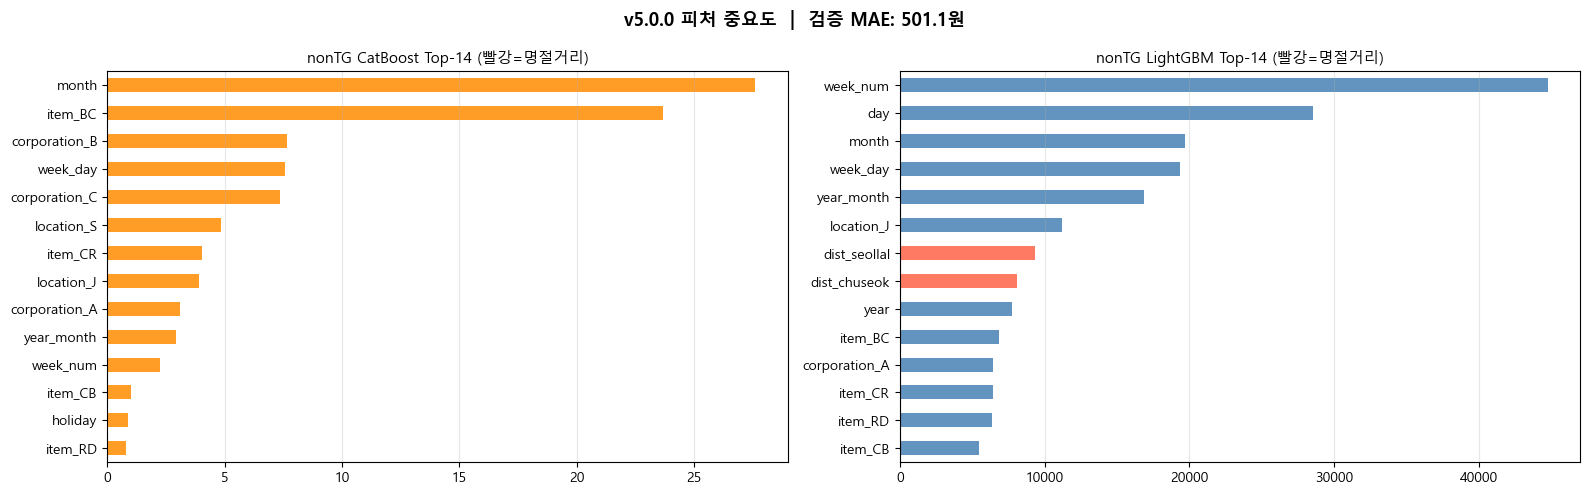


[CatBoost] 명절 거리 피처 순위:
  dist_seollal: 16위 / 22개
  dist_chuseok: 21위 / 22개


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# non-TG CatBoost 피처 중요도
cb_imp = pd.Series(cb_nt.get_feature_importance(), index=FEAT_COLS).sort_values(ascending=False)
colors = ['tomato' if 'dist_' in c else 'darkorange' for c in cb_imp.head(14).index]
cb_imp.head(14).plot(kind='barh', ax=axes[0], color=colors[::-1], alpha=0.85)
axes[0].invert_yaxis()
axes[0].set_title('nonTG CatBoost Top-14 (빨강=명절거리)', fontsize=11)
axes[0].grid(axis='x', alpha=0.3)

# non-TG LightGBM 피처 중요도
lgb_imp = pd.Series(lgb_nt.feature_importances_, index=FEAT_COLS).sort_values(ascending=False)
colors2 = ['tomato' if 'dist_' in c else 'steelblue' for c in lgb_imp.head(14).index]
lgb_imp.head(14).plot(kind='barh', ax=axes[1], color=colors2[::-1], alpha=0.85)
axes[1].invert_yaxis()
axes[1].set_title('nonTG LightGBM Top-14 (빨강=명절거리)', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle(f'v5.0.0 피처 중요도  |  검증 MAE: {mae_all:.1f}원', fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('./results', exist_ok=True)
plt.savefig('./results/feature_importance_v5.0.0.png', dpi=150, bbox_inches='tight')
plt.show()

# 명절 거리 피처의 중요도 순위 출력
print('\n[CatBoost] 명절 거리 피처 순위:')
rank = list(cb_imp.index)
for feat in ['dist_seollal', 'dist_chuseok']:
    if feat in rank:
        print(f'  {feat}: {rank.index(feat)+1}위 / {len(rank)}개')

---
## 12. 후처리 + 제출 파일 생성

후처리 임계값: 품목별 최솟값 미만 예측은 0으로 처리  
이유: 거래 없는 날(일요일 등)의 price=0이 실제 정답에 포함 → 너무 낮은 예측은 0이 맞음

In [15]:
# TG 결과 조립
tg_result = test_dum[tg_te_mask][['ID']].copy()
tg_result['answer'] = pred_tg_final
tg_result['item']   = 'TG'

# non-TG 결과 조립 (item 레이블은 원본 test_pre에서 참조)
nontg_items  = test_pre[test_pre['item'] != 'TG']['item'].values
nontg_result = test_dum[nt_te_mask][['ID']].copy()
nontg_result['answer'] = pred_nt
nontg_result['item']   = nontg_items

result_df = pd.concat([tg_result, nontg_result], axis=0).reset_index(drop=True)

# 후처리: 품목별 최솟값 미만 → 0
# 임계값 출처: 1등 코드 동일 (train 데이터에서 3월 실제 최솟값 기준)
min_thresholds = {'TG': 400, 'CB': 50, 'RD': 10, 'CR': 150, 'BC': 100}
for item, thr in min_thresholds.items():
    mask = (result_df['item'] == item) & (result_df['answer'] < thr)
    result_df.loc[mask, 'answer'] = 0.0
    if mask.sum() > 0:
        print(f'{item}: {mask.sum()}개 → 0 처리')

print('\n예측 통계:')
print(result_df.groupby('item')['answer'].agg(['mean', 'min', 'max']).round(1))

# 제출 파일 생성
result = sub[['ID']].merge(result_df[['ID', 'answer']], on='ID', how='left')
result['answer'] = result['answer'].fillna(0.0)

SUBMISSION_PATH = './results/submission_v5.0.0.csv'
result.to_csv(SUBMISSION_PATH, index=False, encoding='utf-8-sig')
print(f'\n저장 완료: {SUBMISSION_PATH} ({len(result)}행)')

TG: 40개 → 0 처리
CB: 38개 → 0 처리
RD: 1개 → 0 처리
CR: 76개 → 0 처리
BC: 80개 → 0 처리

예측 통계:
        mean  min     max
item                     
BC    1633.8  0.0  2707.9
CB     451.8  0.0   791.2
CR     857.7  0.0  2059.0
RD     387.5  0.0   756.4
TG    3357.5  0.0  5756.0

저장 완료: ./results/submission_v5.0.0.csv (1092행)


---
## 13. 결과 요약

In [16]:
print('=' * 65)
print('  v5.0.0 최종 결과')
print('=' * 65)
print(f'  [검증 방식]  시즌 Hold-Out (2022-03 → 테스트 조건 동일)')
print(f'  [검증 MAE]   {mae_all:.2f}원 (TG: {mae_tg:.2f} / nonTG: {mae_nt:.2f})')
print(f'  [신규 피처]  dist_seollal, dist_chuseok (명절 접근 거리, cap=30일)')
print(f'  [TG 모델]    모델A(item 포함) + 모델B(item 제외) 평균, sqrt 변환')
print(f'  [nonTG 모델] 단일 모델, 원본 price 그대로')
print(f'  [피처 수]    {len(FEAT_COLS)}개 (기본7 + 명절거리2 + one-hot{len(FEAT_COLS)-9})')
print()
print(f'  예상 Public Score ≈ {mae_all * 1.26:.0f}원 (×1.26 배율 가정)')
print(f'  제출 파일: {SUBMISSION_PATH}')
print('=' * 65)

  v5.0.0 최종 결과
  [검증 방식]  시즌 Hold-Out (2022-03 → 테스트 조건 동일)
  [검증 MAE]   501.10원 (TG: 1196.16 / nonTG: 261.42)
  [신규 피처]  dist_seollal, dist_chuseok (명절 접근 거리, cap=30일)
  [TG 모델]    모델A(item 포함) + 모델B(item 제외) 평균, sqrt 변환
  [nonTG 모델] 단일 모델, 원본 price 그대로
  [피처 수]    22개 (기본7 + 명절거리2 + one-hot13)

  예상 Public Score ≈ 631원 (×1.26 배율 가정)
  제출 파일: ./results/submission_v5.0.0.csv


---
### 다음 버전

| 버전 | 내용 |
|------|------|
| **v4.4.0** | 품목별 개별 모델 (TG / CR+RD / CB+BC 분리) |
| **v4.5.0** | 명절 거리 피처 cap 값 튜닝 (15일 / 30일 / 45일 비교) |
| **v5.0.0** | Optuna 하이퍼파라미터 최적화 |